In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')

from src.selectors import LassoSelector, ExtraTreesSelector
from src.selection_pipeline import FeatureSelectionPipeline
from src.utils import build_storm_weights, selection_summary
from src.selection_visualization import plot_lasso_vs_et, plot_et_heatmap

import sklearn

# Feature Selection

## Description

This notebook identifies the optimal predictor subset from the 33 engineered features constructed in the main notebook. Feature selection is performed via two independent methods — weighted LASSO and storm-weighted ExtraTrees — applied across all five forecast horizons (1, 3, 7, 12, 21 hours).

A feature is retained in `SELECTED_FEATURES` if it survives in at least two of two methods at any horizon (intersection, union across horizons). Storm hours (Dst < −50 nT, ~5% of the training set) are upweighted by the inverse storm fraction (~21×) in both methods to prevent suppression of signals concentrated in storm periods [KIS25].

The primary output is `models/feature_selection_results.pkl` — containing strict (min_votes=2) and liberal (min_votes=1) subsets, plus the final `SELECTED_FEATURES` with `d_neutron` force-included on physical grounds.

**Note on method selection:** LASSO identifies features with non-zero linear contribution at the cross-validated penalty level. ExtraTrees captures non-linear dependencies and accepts `sample_weight` directly — avoiding the temporal order violations introduced by oversampling. Mutual Information was excluded because `sample_weight` is not available in this sklearn build.

**Depends on:** `data/processed/feat_split.parquet`, `models/split_masks.pkl`, `models/context_constants.pkl`

**Why a custom pipeline class?** The standard `sklearn.Pipeline` supports a single target and a fixed sequence of transformations. Feature selection across five forecast horizons with different targets, majority vote consolidation, and storage of fitted selector objects for downstream visualisation requires a custom orchestration layer. `FeatureSelectionPipeline` wraps `LassoSelector` and `ExtraTreesSelector` — both sklearn-compatible estimators — and adds the multi-horizon and consolidation logic on top. In the Modelling notebook, standard `sklearn.Pipeline` objects are used for each individual model.

**Why LassoSelector and ExtraTreesSelector?** LASSO identifies features with non-zero linear contribution under $\ell_1$ regularisation — it is fast, interpretable, and directly supports `sample_weight` via `LassoCV`. ExtraTrees captures non-linear interactions and feature combinations that LASSO misses by definition, and also accepts `sample_weight` directly in `fit()`. The two methods are complementary: LASSO filters by linear relevance, ExtraTrees filters by non-linear split gain.

*The following methods were evaluated and excluded: `MISelector` — `sample_weight` unavailable in this sklearn build; `RFECVSelector` — storm-hour oversampling required to compensate violates temporal order under `TimeSeriesSplit`; `SHAPSelector` — computationally prohibitive (~30 min per horizon), retained for the Modelling notebook.*

**Package structure:**
```
src/
├── __init__.py                — package exports
├── selection_pipeline.py      — FeatureSelectionPipeline (orchestrator)
├── selection_visualization.py — plot_lasso_vs_et, plot_et_heatmap
├── utils.py                   — build_storm_weights, selection_summary
└── selectors/
    ├── __init__.py            — selector exports
    ├── base.py                — BaseSelector (abstract)
    ├── lasso.py               — LassoSelector (linear, L1) ✓ used
    ├── extra_trees.py         — ExtraTreesSelector (non-linear, ensemble) ✓ used
    ├── mi.py                  — MISelector (retained — sample_weight unavailable)
    ├── shap.py                — SHAPSelector (retained — Modelling notebook)
    └── feature_selector.py    — backward compatibility shim
```

## Data Loading

Three artifacts produced by the main notebook are loaded:

- `feat_split.parquet` — scaled and imputed feature matrix for all segments
- `split_masks.pkl` — boolean masks defining the six temporal segments
- `context_constants.pkl` — constants (`FEATURE_COLS`, `K_HORIZONS`, `STORM_THR`) defined in the main notebook

Feature selection operates exclusively on `X_train` — the union of Train\_1 and Train\_2 segments. Validation and test segments are not seen at any point during selection.

A scaling check confirms that train features have mean ≈ 0 — verifying that `feat_split.parquet` contains the scaled version of the data.

In [2]:
# ── Data Loading ───────────────────────────────────────────────────────────
feat  = pd.read_parquet('../data/processed/feat_split.parquet')
masks = joblib.load('../models/split_masks.pkl')
ctx   = joblib.load('../models/context_constants.pkl')

FEATURE_COLS = ctx['FEATURE_COLS']
K_HORIZONS   = ctx['K_HORIZONS']
STORM_THR    = ctx['STORM_THR']

# Train segment only — feature selection uses training data exclusively
X_train = feat.loc[masks['train'], FEATURE_COLS]

print(f'feat shape     : {feat.shape}')
print(f'FEATURE_COLS   : {len(FEATURE_COLS)} features')
print(f'K_HORIZONS     : {K_HORIZONS}')
print(f'X_train shape  : {X_train.shape}')
print(f'\nTrain date range: {feat.loc[masks["train"], "datetime"].min()} → '
      f'{feat.loc[masks["train"], "datetime"].max()}')
print(f'\nScaling check (train mean max abs): {X_train.mean().abs().max():.6f}')

feat shape     : (364728, 73)
FEATURE_COLS   : 33 features
K_HORIZONS     : [1, 3, 7, 12, 21]
X_train shape  : (121185, 33)

Train date range: 1995-01-01 00:00:00 → 2008-12-31 02:00:00

Scaling check (train mean max abs): 0.000000


> **Observations — Data Loading:**
> - `feat_split.parquet`: 364,728 rows × 73 columns — scaled and imputed, all segments included.
> - `X_train`: 121,185 rows × 33 features — Train\_1 ∪ Train\_2, purge zones excluded.
> - Train period: 1995-01-01 → 2008-12-31 (Solar Cycles 22–23, Val\_Storm carved out).
> - `K_HORIZONS = [1, 3, 7, 12, 21]` — five forecast horizons.
> - Scaling check confirms mean ≈ 0 — features are correctly standardised.

## Feature Selection Pipeline

Two independent feature selection methods are applied across all five forecast horizons. A feature is retained in `SELECTED_FEATURES` if it survives in both methods at any horizon (intersection per horizon, union across horizons).

| Method | Type | Temporal correctness | Storm weighting |
|---|---|---|---|
| `LassoSelector` | Linear ($\ell_1$ regularisation) | `TimeSeriesSplit` CV for alpha selection | `sample_weight` directly |
| `ExtraTreesSelector` | Non-linear (ensemble) | No CV required | `sample_weight` directly |

### Mathematical Formulation

Feature selection addresses the question: **which of the 33 engineered features carry genuine predictive information about $D_{st}$ at horizon $h$?** Two independent methods with complementary philosophies are applied — one linear, one non-linear. A feature enters `SELECTED_FEATURES` only if both methods confirm its relevance.



**LASSO — linear filter**

LASSO (Least Absolute Shrinkage and Selection Operator) is a linear regression model with a complexity penalty. Given $n$ training observations, we seek a coefficient vector $\beta \in \mathbb{R}^{33}$ such that the linear combination $\hat{y}_i = x_i^T\beta = \sum_j \beta_j x_{ij}$ approximates the target $y_i = D_{st}(t+h)$. The prediction error alone would select all 33 features — regularisation forces the model to explain $D_{st}$ with as few features as possible:

$$\hat{\beta} = \underset{\beta}{\arg\min} \underbrace{\sum_{i=1}^{n} w_i \left(y_i - x_i^T\beta\right)^2}_{\text{weighted prediction error}} + \underbrace{\alpha \sum_j |\beta_j|}_{\ell_1 \text{ complexity penalty}}$$

**Why $\ell_1$ and not $\ell_2$?** The $\ell_2$ penalty ($\sum_j \beta_j^2$, Ridge regression) shrinks all coefficients toward zero but never reaches exactly zero — it reduces but does not eliminate features. The $\ell_1$ penalty ($\sum_j |\beta_j|$) has a geometric property that forces exact zeros: its level sets are diamond-shaped (in 2D) with corners on the axes. The solution $\hat{\beta}$ tends to land at a corner, setting one or more coefficients to exactly zero. This makes LASSO a natural feature selector.

**How the optimisation works.** The objective is solved by coordinate descent: iteratively optimise one $\beta_j$ at a time while holding all others fixed. The solution for each coordinate has a closed form — the soft-thresholding operator — which sets $\hat{\beta}_j = 0$ if the partial correlation of feature $j$ with the residual is below $\alpha/2$. Features whose signal is too weak relative to $\alpha$ are zeroed exactly.

**Parameters in our setting:**
- $y_i$ — target $D_{st}$ at horizon $h$, one model per $h \in \{1, 3, 7, 12, 21\}$
- $x_i \in \mathbb{R}^{33}$ — vector of 33 scaled features at hour $i$ [§5.8]. Scaling is essential: without it, features with large natural variance receive smaller $\beta_j$ and are disproportionately penalised by the $\ell_1$ term
- $w_i = 1/f_{storm}$ for storm hours ($D_{st} < -50$ nT), $w_i = 1$ otherwise. Storm hours represent ~4.71% of the training set — without upweighting, the squared error term is dominated by the quiet-period majority and LASSO ignores features whose signal is concentrated in storms, such as `d_neutron` [KIS25]
- $\alpha > 0$ — regularisation strength, selected by `LassoCV` via `TimeSeriesSplit(n_splits=5)`. At each CV fold, the model is trained on past data only and validated on future data — preventing look-ahead leakage. The $\alpha$ that minimises cross-validated error is selected automatically
- **Selection criterion:** features with $|\hat{\beta}_j| < 10^{-5}$ are excluded. The threshold removes floating-point near-zero artefacts from coordinate descent — not marginal features

**Selection metric:** $|\hat{\beta}_j|$ — absolute value of the cross-validated LASSO coefficient under storm weighting. A feature is retained if its coefficient survives $\ell_1$ shrinkage at the cross-validated penalty level.


**ExtraTrees — non-linear filter**

ExtraTrees (Extremely Randomised Trees) is an ensemble of $T$ decision trees. A single decision tree partitions the feature space by a sequence of binary splits: at each internal node, a feature $j$ and threshold $\tau$ are chosen such that observations with $x_j \leq \tau$ go left and $x_j > \tau$ go right. The split is chosen to maximise the reduction in mean squared error $\Delta\text{MSE}(s)$ — the difference in prediction error before and after the split, weighted by the fraction of observations $p(s)$ reaching that node.

Unlike standard Random Forest which searches for the optimal threshold at each split, ExtraTrees selects the threshold **uniformly at random** from the feature's range. This "extremely randomised" strategy reduces the correlation between trees (increasing ensemble diversity) and is computationally faster. The ensemble of $T=100$ trees averages out the randomness — individual trees are high variance but their mean is stable.

Feature importance is the weighted average reduction in MSE across all splits on feature $j$, averaged over all trees:

$$\text{importance}_j = \frac{1}{T} \sum_{t=1}^{T} \sum_{s \in S_t^j} p(s) \cdot \Delta\text{MSE}(s)$$

where:
- $S_t^j$ — set of all splits on feature $j$ in tree $t$
- $p(s)$ — fraction of training observations reaching split $s$. This normalises by depth: splits near the root affect more observations and receive higher weight
- $\Delta\text{MSE}(s)$ — reduction in mean squared error at split $s$, computed with storm weights $w_i$ propagated through the tree. Storm hours influence splits proportionally to their weight — a split that separates storm from quiet hours will show large $\Delta\text{MSE}$ and be rewarded

**Why ExtraTrees captures what LASSO misses.** LASSO can only detect features with a linear relationship to the target. ExtraTrees detects any feature that helps partition the data into lower-error regions — including non-linear relationships, threshold effects, and interactions between features. For example, `neutron_counts` may show weak linear correlation with $D_{st}$ globally but strong predictive power during Forbush Decrease periods — ExtraTrees can capture this through splits that isolate those periods.

**Parameters in our setting:**
- $T = 100$ trees — sufficient for stable importance estimates at the scale of our training set.
- `threshold_q = 0.50` — features below the median importance are eliminated. The threshold is relative (not absolute) to avoid sensitivity to the scale of importance values, which depends on the number of features and tree depth
- Storm weights $w_i$ passed directly to `fit()` — no resampling required, preserving temporal order

**Selection metric:** $\text{importance}_j$ — weighted mean MSE reduction across all splits on feature $j$ over $T$ trees. A feature is retained if its importance exceeds the median across all 33 features.


**Majority vote consolidation**

Both methods produce surviving feature sets for each of the 5 horizons. Consolidation proceeds in two steps:

*Step 1 — per horizon:* count how many methods retain feature $j$ at horizon $k$:

$$\text{votes}_j^{(k)} = \mathbf{1}[j \in \text{LASSO}_k] + \mathbf{1}[j \in \text{ET}_k] \in \{0, 1, 2\}$$

*Step 2 — across horizons:* take the maximum vote count across all horizons:

$$\text{votes}_j = \max_{k \in \{1,3,7,12,21\}} \text{votes}_j^{(k)}$$

$$\text{SELECTED} = \{j : \text{votes}_j \geq 2\}$$

The $\max$ over horizons implements union — a feature is retained if both methods agree at *any* horizon, not necessarily the same one. This reflects the physical reality that different predictors dominate at different lead times: short-horizon models rely on immediate solar wind state ($B_z$, $V_{sw}$), while long-horizon models draw more on solar cycle phase (`solar_cos`, `solar_sin`) and accumulated IMF (`bz_acc_12h`). Requiring intersection between methods (votes $\geq 2$) ensures a feature must be relevant both linearly and non-linearly at some horizon.

**Consolidation metric:** $\text{votes}_j \in \{0, 1, 2\}$ — number of methods that retain feature $j$ at its best horizon. The strict threshold (votes $= 2$) produces the operative `SELECTED_FEATURES`.

### **Execution and consolidation**

Both methods use storm sample weights ($w = 1/f_{storm} \approx 21\times$) for $D_{st} < -50$ nT — storm hours represent ~5% of the training set but carry the primary Forbush Decrease signal [KIS25].

Two consolidation modes are compared:
- `min_votes=2` (strict / intersection): feature must survive both methods at some horizon
- `min_votes=1` (liberal / union): feature survives if in at least one method at any horizon

In [3]:
# ── Feature Selection Pipeline ────────────────────────────────────────────
# Strict mode (min_votes=2) — feature must survive both LASSO and ExtraTrees
# at any horizon to be included in SELECTED_FEATURES.

pipeline_strict = FeatureSelectionPipeline(
    feature_cols   = FEATURE_COLS,
    k_horizons     = K_HORIZONS,
    storm_thr      = STORM_THR,
    lasso_splits   = 5,
    et_estimators  = 100,
    et_threshold_q = 0.50,
    min_votes      = 2,
    random_state   = 42,
)
pipeline_strict.fit(X_train, feat)

print('\n── Strict (intersection) ──────────────────────────────')
pipeline_strict.print_summary()


── Horizon 1h ──────────────────────────────────
  [1/2] LassoCV...
        alpha=1.641248  retained=17/33
  [2/2] ExtraTreesSelector...
        retained=17/33

── Horizon 3h ──────────────────────────────────
  [1/2] LassoCV...
        alpha=0.468026  retained=21/33
  [2/2] ExtraTreesSelector...
        retained=17/33

── Horizon 7h ──────────────────────────────────
  [1/2] LassoCV...
        alpha=0.311265  retained=20/33
  [2/2] ExtraTreesSelector...
        retained=17/33

── Horizon 12h ──────────────────────────────────
  [1/2] LassoCV...
        alpha=0.199308  retained=22/33
  [2/2] ExtraTreesSelector...
        retained=17/33

── Horizon 21h ──────────────────────────────────
  [1/2] LassoCV...
        alpha=0.456164  retained=18/33
  [2/2] ExtraTreesSelector...
        retained=17/33

── Strict (intersection) ──────────────────────────────

Feature Selection Summary  (min_votes=2)

                       Feature  Max votes   Selected
────────────────────────────────────────

In [4]:
# ── Liberal mode — reuse fitted pipeline, change min_votes only ───────────
pipeline_strict.min_votes = 1
pipeline_strict._consolidate()

print('\n── Liberal (union) ────────────────────────────────────')
pipeline_strict.print_summary()

# Store liberal results before resetting
selected_liberal  = pipeline_strict.get_selected()
vote_counts_lib   = pipeline_strict.vote_counts_.copy()
summary_lib       = pipeline_strict.summary_.copy()

# Restore strict
pipeline_strict.min_votes = 2
pipeline_strict._consolidate()
selected_strict   = pipeline_strict.get_selected()
vote_counts_str   = pipeline_strict.vote_counts_.copy()
summary_str       = pipeline_strict.summary_.copy()

print(f'\nStrict : {len(selected_strict)} features')
print(f'Liberal: {len(selected_liberal)} features')
print(f'Difference (liberal only): {set(selected_liberal) - set(selected_strict)}')


── Liberal (union) ────────────────────────────────────

Feature Selection Summary  (min_votes=1)

                       Feature  Max votes   Selected
───────────────────────────────────────────────────────
                        bz_gsm          2          ✓
                      sw_speed          2          ✓
                    sw_density          2          ✓
                   sw_pressure          2          ✓
                       e_field          2          ✓
                          f107          2          ✓
                   mach_alfven          2          ✓
                neutron_counts          2          ✓
                           ssn          2          ✓
                    bz_acc_12h          2          ✓
                   bz_gsm_lag1          2          ✓
                     bz_acc_6h          2          ✓
                     bz_acc_3h          2          ✓
                 sw_speed_lag1          2          ✓
                  bz_gsm_lag21          2        

> **Observations — Feature Selection Pipeline:**
> - **LASSO alpha by horizon:** Highest at h=1h (α=1.641) — strongest regularisation, only 17/33 features retained. Decreases to h=12h (α=0.199, 22/33 retained) — longer horizons distribute the signal across more features. Rises again at h=21h (α=0.456, 18/33) — at the longest horizon the signal weakens and fewer features survive.
> - **ExtraTrees retention:** Stable at 17/33 across all horizons — the top 50% importance threshold (threshold_q=0.50) produces a consistent set regardless of horizon. This stability reflects that ExtraTrees global importance is less sensitive to the target shift than LASSO alpha.
> - **Strict (min_votes=2):** 23/33 features survive both methods at at least one horizon. `dbz_dt` is the only feature with votes=0 — eliminated by both methods at all horizons. Features with votes=1 survive one method only and are excluded from the strict subset.
> - **Liberal (min_votes=1):** 32/33 features survive — only `dbz_dt` is eliminated. Features with votes=1 survive LASSO at some horizon but fall below the ExtraTrees top-50% threshold globally.
> - **`d_neutron`:** votes=1 in strict mode — survives storm-weighted LASSO at h=7h but falls below ExtraTrees median importance at all horizons. This reflects the event-driven nature of the Forbush Decrease signal (0.6% of records) — global importance metrics systematically underestimate episodic predictors. Physical motivation [KIS25] warrants force-inclusion (see below).

## Results

`d_neutron` is force-included in `SELECTED_FEATURES` on physical grounds. Kisvárdai et al. (2025) [KIS25] demonstrate that neutron monitor correlation with Dst increases from 0.306 to 0.555 during Forbush Decrease periods — the differential flux `d_neutron` is the primary carrier of this signal. The feature survives storm-weighted LASSO at h=7h, confirming non-zero linear contribution when storm periods receive appropriate emphasis. ExtraTrees global importance (computed over the full training set) underestimates event-driven signals concentrated in 0.6% of records — this is a known limitation of split-gain importance in heavily imbalanced datasets, not evidence of irrelevance. The definitive importance assessment is deferred to SHAP values in the Modelling notebook.

In [5]:
# ── d_neutron diagnostic — motivation for force-include ──────────────────
# Използваме fitted обектите от pipeline — без повторен fit

et7    = pipeline_strict.fitted_selectors_['extra_trees'][7]
lasso7 = pipeline_strict.fitted_selectors_['lasso'][7]

# ExtraTrees importance vs median threshold per horizon
print("=== ExtraTrees importance — d_neutron vs median threshold ===")
for k in K_HORIZONS:
    et  = pipeline_strict.fitted_selectors_['extra_trees'][k]
    imp = et.importances_['d_neutron']
    thr = et.importances_.quantile(0.50)
    print(f"  h={k:2d}h  importance={imp:.6f}  median={thr:.6f}  "
          f"{'✓ retained' if imp >= thr else '✗ below median'}")

# LASSO coefficient at h=7h
print(f"\n=== LASSO coefficient — d_neutron at h=7h (storm-weighted) ===")
print(f"  alpha      : {lasso7.alpha_:.6f}")
print(f"  coefficient: {lasso7.coef_['d_neutron']:.6f}  "
      f"{'✓ non-zero' if abs(lasso7.coef_['d_neutron']) > 1e-5 else '✗ zeroed'}")

# Forbush period statistics — 2,259 hours verified in EDA Anomalies section
print(f"\n=== Forbush period statistics ===")
print(f"  Forbush Decrease candidates (EDA)    : 2,259 hours (0.619% of full record)")
print(f"  Storm hours (Dst < -50 nT) in train  : "
      f"{(feat.loc[masks['train'], 'dst'] < -50).sum():,} "
      f"({(feat.loc[masks['train'], 'dst'] < -50).mean()*100:.2f}%)")

=== ExtraTrees importance — d_neutron vs median threshold ===
  h= 1h  importance=0.003057  median=0.016930  ✗ below median
  h= 3h  importance=0.006482  median=0.017978  ✗ below median
  h= 7h  importance=0.009576  median=0.023522  ✗ below median
  h=12h  importance=0.008146  median=0.026957  ✗ below median
  h=21h  importance=0.007101  median=0.023462  ✗ below median

=== LASSO coefficient — d_neutron at h=7h (storm-weighted) ===
  alpha      : 0.311265
  coefficient: 0.173924  ✓ non-zero

=== Forbush period statistics ===
  Forbush Decrease candidates (EDA)    : 2,259 hours (0.619% of full record)
  Storm hours (Dst < -50 nT) in train  : 5,704 (4.71%)


In [1]:
# ── Figure 1: LASSO vs ExtraTrees at h=7h ────────────────────────────────
# Two-panel comparison showing linear (LASSO) vs non-linear (ExtraTrees)
# feature importance at the primary forecast horizon h=7h.
# d_neutron highlighted in red — survives LASSO but falls below ET median.
plot_lasso_vs_et(
    coef        = lasso7.coef_,
    importances = lasso7.importances_,
    horizon     = 7,
    save_path   = '../images/feature_selection_h7_comparison.png',
)

NameError: name 'plot_lasso_vs_et' is not defined

Saved: ../images/feature_selection_heatmap.png


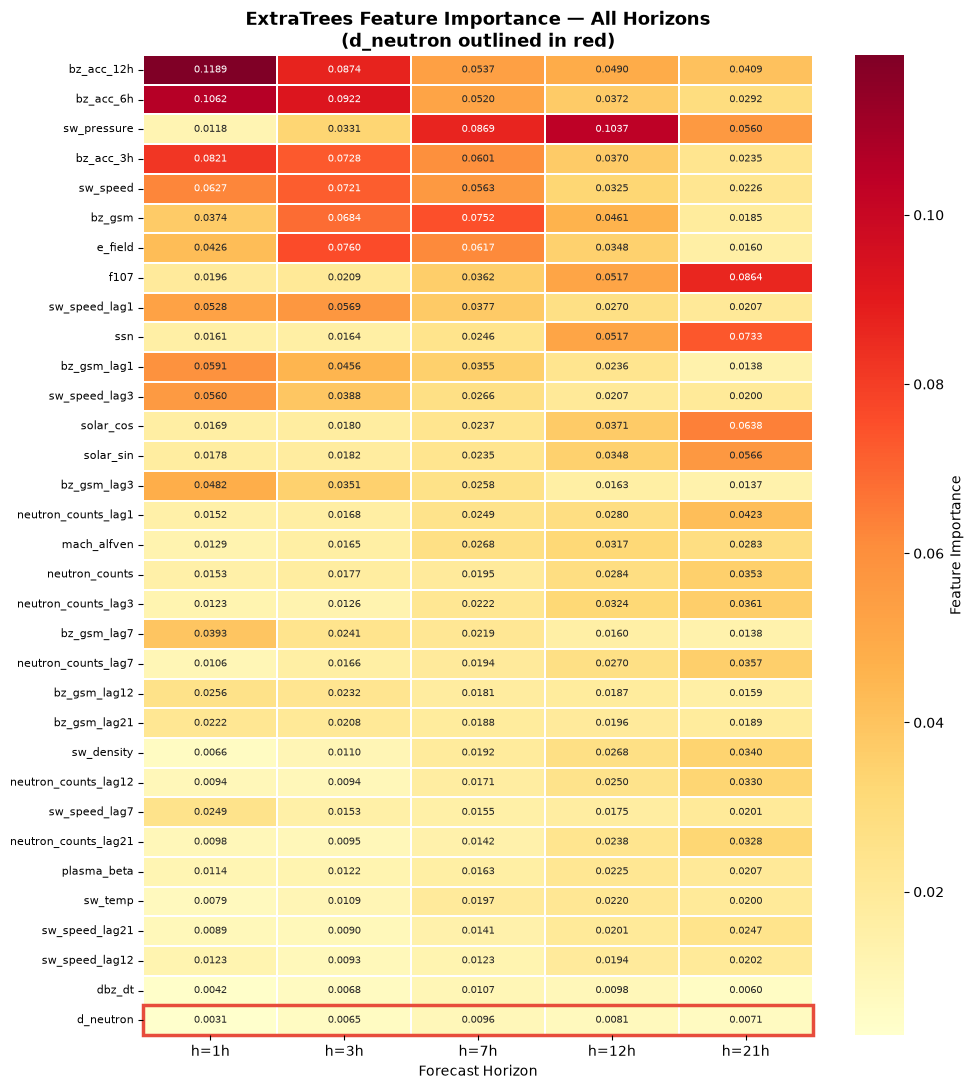

In [7]:
# ── Figure 2: ExtraTrees importance heatmap — all horizons ───────────────
# Heatmap of ExtraTrees importances across all five forecast horizons.
# d_neutron outlined in red — consistently below median at all horizons.
imp_matrix = {
    f'h={k}h': pipeline_strict.fitted_selectors_['extra_trees'][k].importances_
    for k in K_HORIZONS
}
plot_et_heatmap(
    imp_matrix = imp_matrix,
    save_path  = '../images/feature_selection_heatmap.png',
)

> **Observations — d_neutron Diagnostic:**
> - ExtraTrees importance of `d_neutron` ranges from 0.003 to 0.010 across all horizons — consistently below the median threshold (0.017–0.027). This reflects the event-driven nature of the Forbush Decrease signal: ExtraTrees split-gain importance is computed over the full training set where quiet periods dominate (95.3% of train hours have Dst > −50 nT), systematically underestimating features whose signal is concentrated in rare events.
> - Storm-weighted LASSO at h=7h (α=0.311, w=21.2×) assigns `d_neutron` a non-zero coefficient of 0.174 — confirming a detectable linear contribution when storm periods receive appropriate emphasis.
> - Forbush Decrease candidates identified in EDA: 2,259 hours (0.619% of full record). Storm hours (Dst < −50 nT) in train: 5,704 hours (4.71%). Storm weighting at w=21.2× amplifies precisely the periods where `d_neutron` carries signal [KIS25].


In [8]:
# ── Final SELECTED_FEATURES ───────────────────────────────────────────────
# Base: strict subset (min_votes=2)
# d_neutron force-included — physical motivation [KIS25]

SELECTED_FEATURES = list(selected_strict)

if 'd_neutron' not in SELECTED_FEATURES:
    SELECTED_FEATURES.append('d_neutron')
    print("d_neutron force-included — physical motivation [KIS25]")
    print("Reason: event-driven signal concentrated in 0.6% Forbush periods;")
    print("        global importance metrics underestimate episodic predictors.")

print(f'\nFinal SELECTED_FEATURES : {len(SELECTED_FEATURES)} / {len(FEATURE_COLS)}')
print(f'\nFeatures:')
for f in sorted(SELECTED_FEATURES):
    print(f'  {f}')

d_neutron force-included — physical motivation [KIS25]
Reason: event-driven signal concentrated in 0.6% Forbush periods;
        global importance metrics underestimate episodic predictors.

Final SELECTED_FEATURES : 24 / 33

Features:
  bz_acc_12h
  bz_acc_3h
  bz_acc_6h
  bz_gsm
  bz_gsm_lag1
  bz_gsm_lag12
  bz_gsm_lag21
  bz_gsm_lag3
  d_neutron
  e_field
  f107
  mach_alfven
  neutron_counts
  neutron_counts_lag3
  neutron_counts_lag7
  solar_cos
  solar_sin
  ssn
  sw_density
  sw_pressure
  sw_speed
  sw_speed_lag1
  sw_speed_lag3
  sw_speed_lag7


> **Observations — Neutron lag structure:**
> - When predicting `dst_target_7h`, `neutron_counts` looks 7 hours back from the predicted moment, `neutron_counts_lag3` looks 10 hours back, and `neutron_counts_lag7` looks 14 hours back. These are three different snapshots of the same physical signal at different points in the precursor window — not three copies of the same information.
> - The same physical lead time can be reached by different combinations: `neutron_counts_lag7` at h=7h is equivalent to `neutron_counts` at h=14h. This means the useful lag set is not fixed — it shifts with the forecast horizon.
> - Whether the three retained lags carry independent signal above each other cannot be determined from screening alone. This is addressed in the Modelling notebook via SHAP values and ablation.

> **Observations — Final SELECTED_FEATURES:**
> - `SELECTED_FEATURES` contains 24 features: 23 from strict intersection + `d_neutron` force-included.
> - `dbz_dt` is the only feature eliminated by both methods at all horizons — IMF rotation rate carries no consistent predictive signal across horizons or methods.
> - `neutron_counts`, `neutron_counts_lag3`, `neutron_counts_lag7` are retained in strict — consistent with the 7–21h lead time of the Forbush Decrease signal [KIS25].
> - `solar_sin` and `solar_cos` are both retained — solar cycle phase encoding survives both linear and non-linear screening.

## Save Results

The full pipeline results are saved to `models/feature_selection_results.pkl` for consumption by the modelling notebook. The dictionary contains the final `SELECTED_FEATURES`, both strict and liberal subsets, vote counts, per-method per-horizon selections, and summary matrices — preserving the full audit trail of the feature selection process.

The modelling notebook loads `selected_final` as `SELECTED_FEATURES`.

In [9]:
# ── Save Results ───────────────────────────────────────────────────────────

results = {
    'selected_final'     : SELECTED_FEATURES,
    'selected_strict'    : selected_strict,
    'selected_liberal'   : selected_liberal,
    'summary_strict'     : summary_str,
    'summary_liberal'    : summary_lib,
    'vote_counts_strict' : vote_counts_str,
    'vote_counts_liberal': vote_counts_lib,
    'results_per_horizon': pipeline_strict.results_,
    # ── Full pipeline statistics ──────────────────────────────────────────
    'lasso_alpha'        : {k: pipeline_strict.fitted_selectors_['lasso'][k].alpha_
                            for k in K_HORIZONS},
    'lasso_coef'         : {k: pipeline_strict.fitted_selectors_['lasso'][k].coef_
                            for k in K_HORIZONS},
    'et_importances'     : {k: pipeline_strict.fitted_selectors_['extra_trees'][k].importances_
                            for k in K_HORIZONS},
    'vote_counts_raw'    : pipeline_strict.vote_counts_,
    'summary_matrix'     : pipeline_strict.summary_,
}

joblib.dump(results, '../models/feature_selection_results.pkl')
print('Saved: ../models/feature_selection_results.pkl')
print(f'\nFinal   : {len(results["selected_final"])} features')
print(f'Strict  : {len(results["selected_strict"])} features')
print(f'Liberal : {len(results["selected_liberal"])} features')
print(f'\nSELECTED_FEATURES (final):')
for f in results['selected_final']:
    print(f'  {f}')

Saved: ../models/feature_selection_results.pkl

Final   : 24 features
Strict  : 23 features
Liberal : 32 features

SELECTED_FEATURES (final):
  bz_gsm
  sw_speed
  sw_density
  sw_pressure
  e_field
  mach_alfven
  f107
  ssn
  neutron_counts
  bz_acc_3h
  bz_acc_6h
  bz_acc_12h
  bz_gsm_lag1
  bz_gsm_lag3
  bz_gsm_lag12
  bz_gsm_lag21
  sw_speed_lag1
  sw_speed_lag3
  sw_speed_lag7
  neutron_counts_lag3
  neutron_counts_lag7
  solar_sin
  solar_cos
  d_neutron


> **Observations — Save Results:**
> - `models/feature_selection_results.pkl` saved with full audit trail.
> - `selected_final` (24 features) is the operative subset for the Modelling notebook.
> - `selected_strict` (23) and `selected_liberal` (32) are retained for sensitivity analysis.
> - `results_per_horizon` preserves per-method per-horizon selections for reproducibility.